Simulation is running
Simulation complete! 


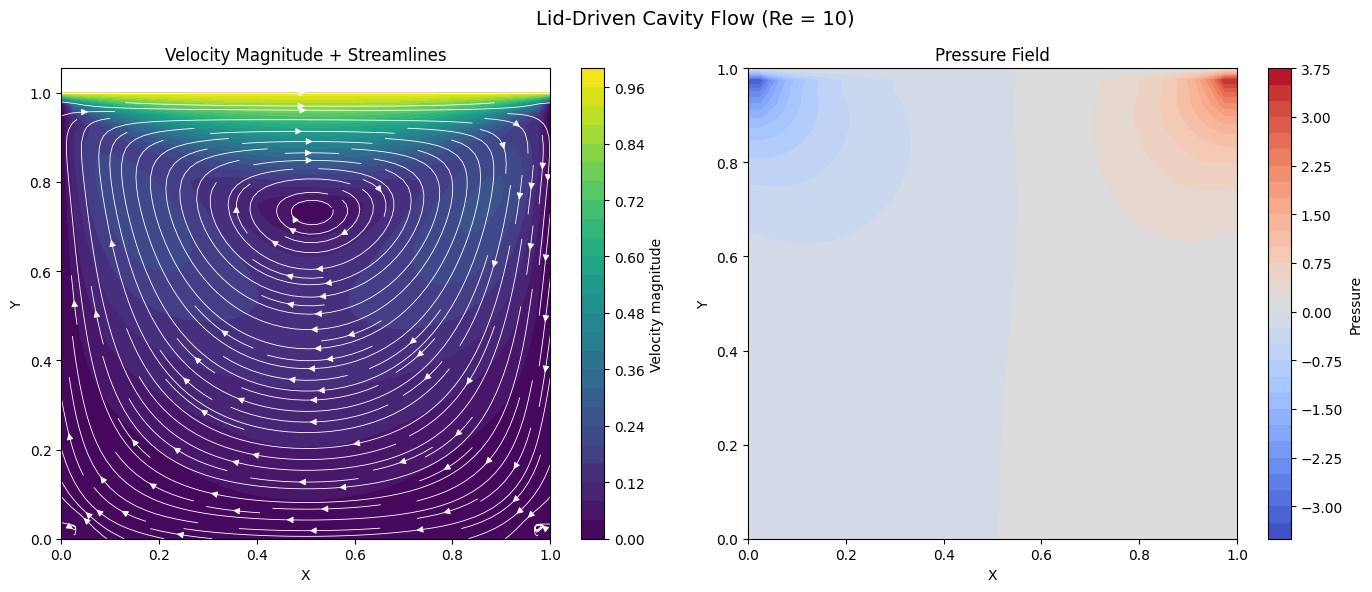

Reynolds number: 10.0
Grid size: 41 x 41
Max velocity: 1.0000


In [3]:


import numpy as np
import matplotlib.pyplot as plt


nx, ny = 41, 41          # Grid points (resolution)
nt = 500                 # Number of time steps
nit = 50                 # Pressure Poisson iterations
lid_velocity = 1.0       # Top wall (lid) velocity - aap change kar sakti hain
rho = 1.0                 # Density
nu = 0.1                  # Kinematic viscosity - aap change kar sakti hain
dt = 0.001                 # Time step

# ---------------- Grid setup ----------------
L = 1.0
dx = L / (nx - 1)
dy = L / (ny - 1)
x = np.linspace(0, L, nx)
y = np.linspace(0, L, ny)
X, Y = np.meshgrid(x, y)

u = np.zeros((ny, nx))
v = np.zeros((ny, nx))
p = np.zeros((ny, nx))
b = np.zeros((ny, nx))

# ---------------- Pressure Poisson solver ----------------
def pressure_poisson(p, b, dx, dy, nit):
    for _ in range(nit):
        pn = p.copy()
        p[1:-1, 1:-1] = (
            ((pn[1:-1, 2:] + pn[1:-1, :-2]) * dy**2 +
             (pn[2:, 1:-1] + pn[:-2, 1:-1]) * dx**2) /
            (2 * (dx**2 + dy**2)) -
            dx**2 * dy**2 / (2 * (dx**2 + dy**2)) * b[1:-1, 1:-1]
        )
        # Boundary conditions for pressure
        p[:, -1] = p[:, -2]   # dp/dx = 0 at x = L
        p[0, :] = p[1, :]     # dp/dy = 0 at y = 0
        p[:, 0] = p[:, 1]     # dp/dx = 0 at x = 0
        p[-1, :] = 0          # p = 0 at y = L (top)
    return p

# ---------------- Build RHS term for pressure equation ----------------
def build_rhs(b, rho, dt, u, v, dx, dy):
    b[1:-1, 1:-1] = rho * (
        1 / dt * ((u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx) +
                  (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)) -
        ((u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx))**2 -
        2 * ((u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dy) *
             (v[1:-1, 2:] - v[1:-1, :-2]) / (2 * dx)) -
        ((v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy))**2
    )
    return b

# ---------------- Main simulation loop ----------------
print("Simulation is running")

for step in range(nt):
    un = u.copy()
    vn = v.copy()

    b = build_rhs(b, rho, dt, u, v, dx, dy)
    p = pressure_poisson(p, b, dx, dy, nit)

    u[1:-1, 1:-1] = (
        un[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt / dx * (un[1:-1, 1:-1] - un[1:-1, :-2])
        - vn[1:-1, 1:-1] * dt / dy * (un[1:-1, 1:-1] - un[:-2, 1:-1])
        - dt / (2 * rho * dx) * (p[1:-1, 2:] - p[1:-1, :-2])
        + nu * (dt / dx**2 * (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, :-2])
              + dt / dy**2 * (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[:-2, 1:-1]))
    )

    v[1:-1, 1:-1] = (
        vn[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt / dx * (vn[1:-1, 1:-1] - vn[1:-1, :-2])
        - vn[1:-1, 1:-1] * dt / dy * (vn[1:-1, 1:-1] - vn[:-2, 1:-1])
        - dt / (2 * rho * dy) * (p[2:, 1:-1] - p[:-2, 1:-1])
        + nu * (dt / dx**2 * (vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, :-2])
              + dt / dy**2 * (vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[:-2, 1:-1]))
    )

    # Boundary conditions (walls = no-slip, top lid moving)
    u[0, :] = 0
    u[:, 0] = 0
    u[:, -1] = 0
    u[-1, :] = lid_velocity   # Top lid moving
    v[0, :] = 0
    v[-1, :] = 0
    v[:, 0] = 0
    v[:, -1] = 0

print("Simulation complete! ")

# ---------------- Plot Results ----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Velocity magnitude contour + streamlines
vel_mag = np.sqrt(u**2 + v**2)
c1 = axes[0].contourf(X, Y, vel_mag, levels=30, cmap='viridis')
axes[0].streamplot(X, Y, u, v, color='white', linewidth=0.6, density=1.5)
axes[0].set_title('Velocity Magnitude + Streamlines')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
fig.colorbar(c1, ax=axes[0], label='Velocity magnitude')

# Pressure contour
c2 = axes[1].contourf(X, Y, p, levels=30, cmap='coolwarm')
axes[1].set_title('Pressure Field')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
fig.colorbar(c2, ax=axes[1], label='Pressure')

plt.suptitle(f'Lid-Driven Cavity Flow (Re = {int(lid_velocity*L/nu)})', fontsize=14)
plt.tight_layout()
plt.savefig('cfd_result.png', dpi=150)
plt.show()

print(f"Reynolds number: {lid_velocity*L/nu:.1f}")
print(f"Grid size: {nx} x {ny}")
print(f"Max velocity: {vel_mag.max():.4f}")